# Portfolio Risk & Robo-Advisor Allocation Engine

End-to-end walkthrough using `src/etl_pipeline.py` and `src/portfolio_optimization.py`.

**Data:** real daily prices (30 tickers, 2013–2018) + synthetic client profiles.  
**SQLite:** `../data/processed/portfolio.db` · **SQL:** `../sql/queries.sql`

## 1. Load & Inspect Data

In [1]:
import sys
import sqlite3
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from etl_pipeline import load_data, compute_returns, DB_PATH
from portfolio_optimization import (
    BOND_PROXY_TICKERS,
    EQUITY_PROXY_TICKERS,
    RISK_FREE_RATE,
    RISK_TIER_TARGET_VOLATILITY,
    assign_clients_to_portfolios,
    build_60_40_benchmark,
    build_tier_portfolios,
    calculate_sharpe_ratio,
    calculate_var,
    compare_to_60_40_benchmark,
    compute_expected_returns_and_risk,
    evaluate_tier_risk_metrics,
    feasible_volatility_bounds,
    optimize_for_target_volatility,
    portfolio_daily_returns,
    simulate_rebalancing,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

prices, profiles = load_data()
returns = compute_returns(prices)

print(f"Price rows: {len(prices):,}  |  shape={prices.shape}")
print(f"Client rows: {len(profiles):,}  |  shape={profiles.shape}")
print(f"Date range: {prices['date'].min().date()} → {prices['date'].max().date()}")
print(f"Tickers ({prices['Name'].nunique()}): {sorted(prices['Name'].unique())}")
print(f"Daily returns shape: {returns.shape}")
print("\nClients per risk tier:")
print(profiles["risk_tier"].value_counts().sort_index().to_string())

display(prices.head())
display(profiles.head())


Price rows: 37,770  |  shape=(37770, 7)
Client rows: 200  |  shape=(200, 6)
Date range: 2013-02-08 → 2018-02-07
Tickers (30): ['AAPL', 'ABT', 'ADBE', 'AIG', 'AMZN', 'BA', 'BAC', 'CVX', 'DIS', 'DUK', 'GE', 'GOOGL', 'GS', 'HON', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MSFT', 'NKE', 'PEP', 'PFE', 'SBUX', 'SO', 'T', 'UNH', 'VZ', 'WMT', 'XOM']
Daily returns shape: (1258, 30)

Clients per risk tier:
risk_tier
Aggressive      47
Conservative    72
Moderate        81


,date,open,high,low,close,volume,Name
0,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL
1,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL
2,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL
3,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL
4,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL


,client_id,age,income_bracket,investment_horizon_years,risk_tolerance_score,risk_tier
0,1,37,$200k+,23,10,Aggressive
1,2,63,$100k-$200k,9,2,Conservative
2,3,70,$50k-$100k,6,3,Conservative
3,4,45,$50k-$100k,17,4,Moderate
4,5,57,$100k-$200k,8,5,Moderate


**Takeaway:** The engine runs on ~37.8k real daily OHLCV rows across 30 multi-sector tickers (2013–2018) and 200 synthetic clients skewed toward Moderate, then Conservative, then Aggressive.

## 2. SQL Exploratory Queries

Sanity checks against `portfolio.db`, then an AAPL `LAG()` spot-check versus pandas returns.

In [2]:
def run_query(sql: str, db_path: Path = DB_PATH) -> pd.DataFrame:
    with sqlite3.connect(db_path) as conn:
        return pd.read_sql_query(sql, conn)


print(f"DB exists: {DB_PATH.resolve().exists()}")

DB exists: True


### 2.1 Date range / ticker count

In [3]:
q1 = """
SELECT MIN(date) AS start_date, MAX(date) AS end_date,
       COUNT(DISTINCT ticker) AS n_tickers, COUNT(*) AS n_rows
FROM prices
"""
print(q1.strip())
run_query(q1)

SELECT MIN(date) AS start_date, MAX(date) AS end_date,
       COUNT(DISTINCT ticker) AS n_tickers, COUNT(*) AS n_rows
FROM prices


,start_date,end_date,n_tickers,n_rows
0,2013-02-08,2018-02-07,30,37770


### 2.2 Average close by ticker

In [4]:
q2 = """
SELECT ticker, ROUND(AVG(close), 2) AS avg_close
FROM prices GROUP BY ticker ORDER BY avg_close DESC
"""
print(q2.strip())
run_query(q2)

SELECT ticker, ROUND(AVG(close), 2) AS avg_close
FROM prices GROUP BY ticker ORDER BY avg_close DESC


,ticker,avg_close
0,GOOGL,682.23
1,AMZN,576.88
2,GS,187.53
3,MMM,160.31
4,BA,149.91
5,UNH,121.00
6,MCD,114.20
7,CVX,109.97
8,AAPL,109.07
9,JNJ,107.34


### 2.3 Clients by risk tier

In [5]:
q3 = """
SELECT risk_tier, COUNT(*) AS num_clients, ROUND(AVG(age), 1) AS avg_age
FROM client_profiles GROUP BY risk_tier ORDER BY risk_tier
"""
print(q3.strip())
run_query(q3)

SELECT risk_tier, COUNT(*) AS num_clients, ROUND(AVG(age), 1) AS avg_age
FROM client_profiles GROUP BY risk_tier ORDER BY risk_tier


,risk_tier,num_clients,avg_age
0,Aggressive,47,33.3
1,Conservative,72,61.2
2,Moderate,81,48.5


### 2.4 Risk tier × income bracket

In [6]:
q4 = """
SELECT risk_tier, income_bracket, COUNT(*) AS num_clients
FROM client_profiles
GROUP BY risk_tier, income_bracket
ORDER BY risk_tier, income_bracket
"""
print(q4.strip())
run_query(q4)

SELECT risk_tier, income_bracket, COUNT(*) AS num_clients
FROM client_profiles
GROUP BY risk_tier, income_bracket
ORDER BY risk_tier, income_bracket


,risk_tier,income_bracket,num_clients
0,Aggressive,$100k-$200k,11
1,Aggressive,$200k+,10
2,Aggressive,$50k-$100k,18
3,Aggressive,<$50k,8
4,Conservative,$100k-$200k,20
5,Conservative,$200k+,9
6,Conservative,$50k-$100k,19
7,Conservative,<$50k,24
8,Moderate,$100k-$200k,29
9,Moderate,$200k+,11


### 2.5 AAPL `LAG()` vs pandas returns

In [7]:
q5 = """
SELECT date, ticker, close,
       LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS prev_close,
       close - LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS daily_change,
       (close - LAG(close) OVER (PARTITION BY ticker ORDER BY date))
           / LAG(close) OVER (PARTITION BY ticker ORDER BY date) AS daily_return
FROM prices WHERE ticker = 'AAPL' ORDER BY date
"""
aapl_sql = run_query(q5)
aapl_sql["date"] = pd.to_datetime(aapl_sql["date"])

aapl_px = (
    prices.sort_values("date")
    .pivot(index="date", columns="Name", values="close")["AAPL"]
    .sort_index()
)
aapl_pd = pd.DataFrame({
    "pandas_daily_change": aapl_px.diff(),
    "pandas_daily_return": aapl_px.pct_change(),
}).reset_index()

spot = ["2013-02-11", "2014-06-09", "2015-08-24", "2016-01-15", "2017-12-29"]
comparison = (
    aapl_sql.merge(aapl_pd, on="date", how="inner")
    .loc[lambda d: d["date"].isin(pd.to_datetime(spot))]
    .assign(
        change_match=lambda d: np.isclose(d["daily_change"], d["pandas_daily_change"], atol=1e-9),
        return_match=lambda d: np.isclose(d["daily_return"], d["pandas_daily_return"], atol=1e-12),
    )[
        ["date", "daily_change", "pandas_daily_change", "daily_return",
         "pandas_daily_return", "change_match", "return_match"]
    ]
)
display(comparison)
assert comparison["change_match"].all() and comparison["return_match"].all()
print("All AAPL spot-checks match.")

,date,daily_change,pandas_daily_change,daily_return,pandas_daily_return,change_match,return_match
1,2013-02-11,0.7072,0.7072,0.010422,0.010422,True,True
334,2014-06-09,1.4758,1.4758,0.016002,0.016002,True,True
639,2015-08-24,-2.6400,-2.6400,-0.024962,-0.024962,True,True
739,2016-01-15,-2.3900,-2.3900,-0.024015,-0.024015,True,True
1232,2017-12-29,-1.8500,-1.8500,-0.010814,-0.010814,True,True


All AAPL spot-checks match.


**Takeaway:** SQL and pandas agree on AAPL daily changes/returns, so the SQLite load and return pipeline are consistent before optimization.

## 3. MPT Optimization

Expected returns / covariance via PyPortfolioOpt, three `efficient_risk` tiers, and assignment of synthetic clients.

In [8]:
mu, cov = compute_expected_returns_and_risk(returns)
min_vol, max_vol = feasible_volatility_bounds(mu, cov)
print(f"Feasible frontier vol range: {min_vol:.2%} – {max_vol:.2%}")

tier_portfolios = build_tier_portfolios(mu, cov)
clients = assign_clients_to_portfolios(profiles, tier_portfolios)

for tier, payload in tier_portfolios.items():
    perf = payload["performance"]
    print(
        f"{tier}: used_vol={payload['used_volatility']:.2%} | "
        f"E[r]={perf['expected_annual_return']:.2%} | "
        f"vol={perf['annual_volatility']:.2%} | "
        f"Sharpe={perf['sharpe_ratio']:.3f} | "
        f"n_assets={len(payload['weights'])}"
    )

Feasible frontier vol range: 9.71% – 28.95%


Conservative: used_vol=9.71% | E[r]=6.77% | vol=9.71% | Sharpe=0.492 | n_assets=17
Moderate: used_vol=14.00% | E[r]=30.13% | vol=14.00% | Sharpe=2.009 | n_assets=8
Aggressive: used_vol=22.00% | E[r]=38.93% | vol=22.00% | Sharpe=1.678 | n_assets=3


### 3.1 Correlation heatmap

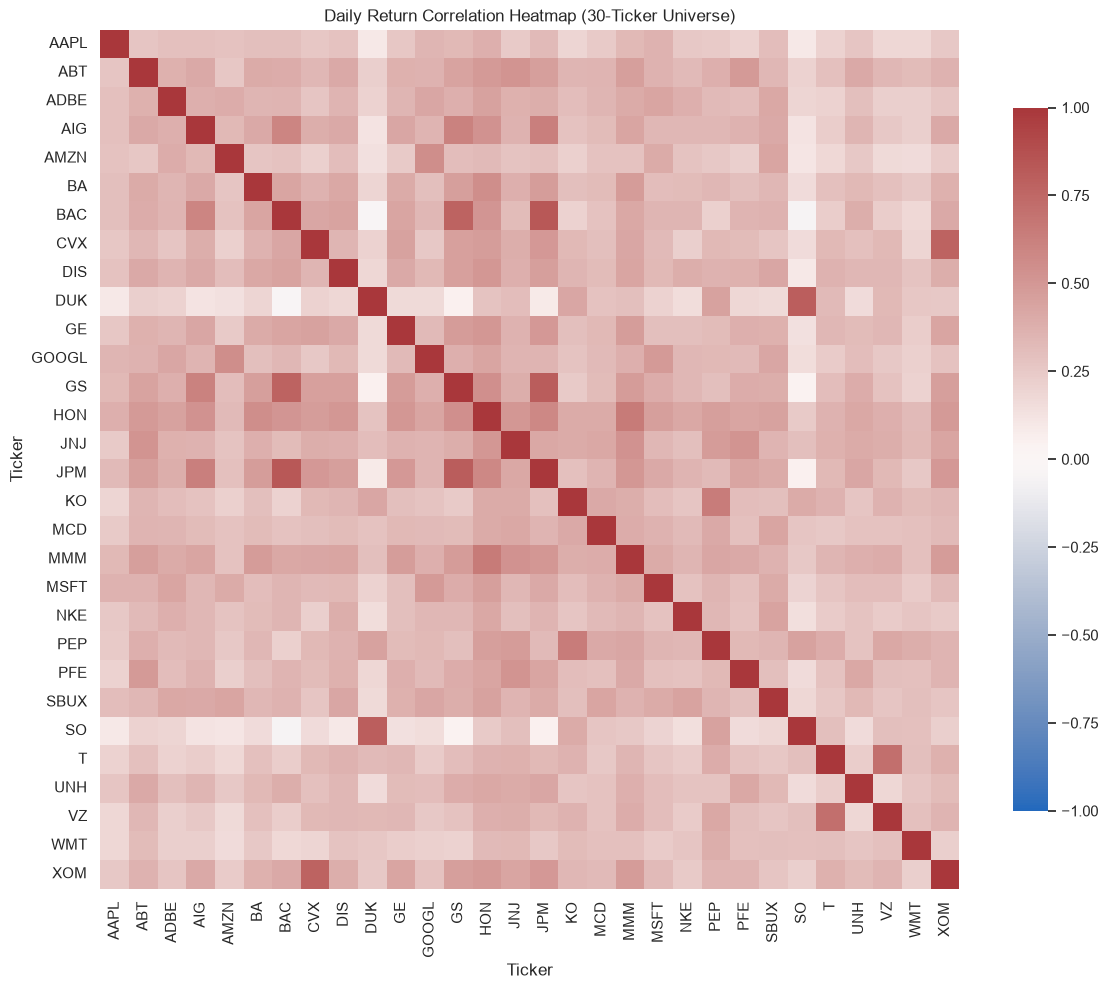

In [9]:
corr = returns.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, ax=ax, cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True, xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.8},
)
ax.set_title("Daily Return Correlation Heatmap (30-Ticker Universe)")
ax.set_xlabel("Ticker")
ax.set_ylabel("Ticker")
plt.tight_layout()
plt.show()

**Takeaway:** Correlations are mostly positive across the equity universe, so diversification helps but does not eliminate market-wide risk.

### 3.2 Efficient frontier with tier portfolios marked

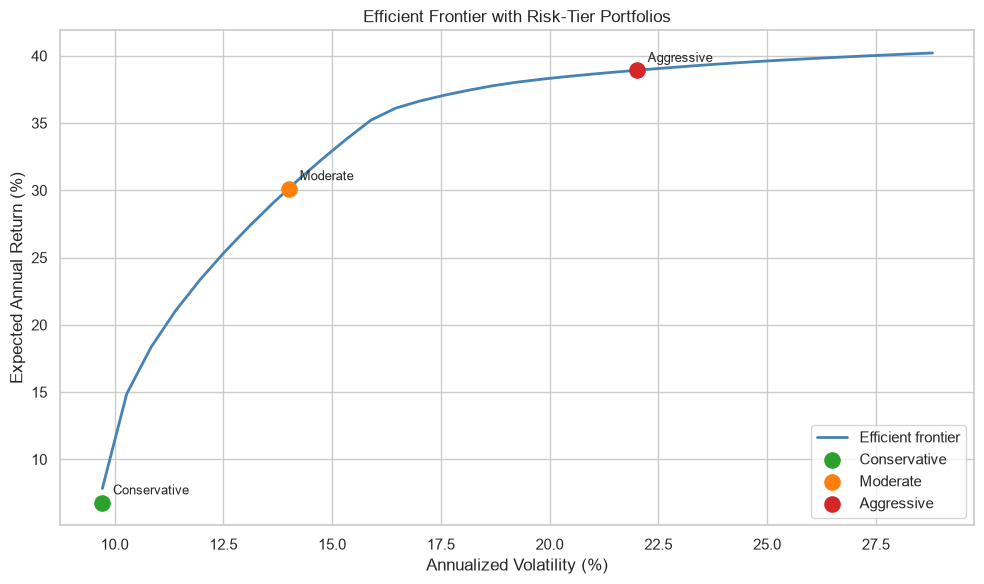

In [10]:
vol_grid = np.linspace(min_vol * 1.001, max_vol * 0.995, 35)
frontier_vols, frontier_rets = [], []
for tv in vol_grid:
    _, perf, used = optimize_for_target_volatility(
        mu, cov, float(tv), vol_bounds=(min_vol, max_vol)
    )
    frontier_vols.append(perf[1])
    frontier_rets.append(perf[0])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    np.array(frontier_vols) * 100,
    np.array(frontier_rets) * 100,
    color="steelblue", lw=2, label="Efficient frontier",
)

tier_colors = {"Conservative": "#2ca02c", "Moderate": "#ff7f0e", "Aggressive": "#d62728"}
for tier, payload in tier_portfolios.items():
    perf = payload["performance"]
    ax.scatter(
        perf["annual_volatility"] * 100,
        perf["expected_annual_return"] * 100,
        s=120, color=tier_colors[tier], zorder=5, label=tier,
    )
    ax.annotate(
        tier,
        (perf["annual_volatility"] * 100, perf["expected_annual_return"] * 100),
        textcoords="offset points", xytext=(8, 6), fontsize=9,
    )

ax.set_title("Efficient Frontier with Risk-Tier Portfolios")
ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Expected Annual Return (%)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Takeaway:** Conservative sits at the minimum-variance end of the frontier (8% target was infeasible), while Moderate and Aggressive climb the curve toward higher expected return and risk.

### 3.3 Portfolio weights by tier

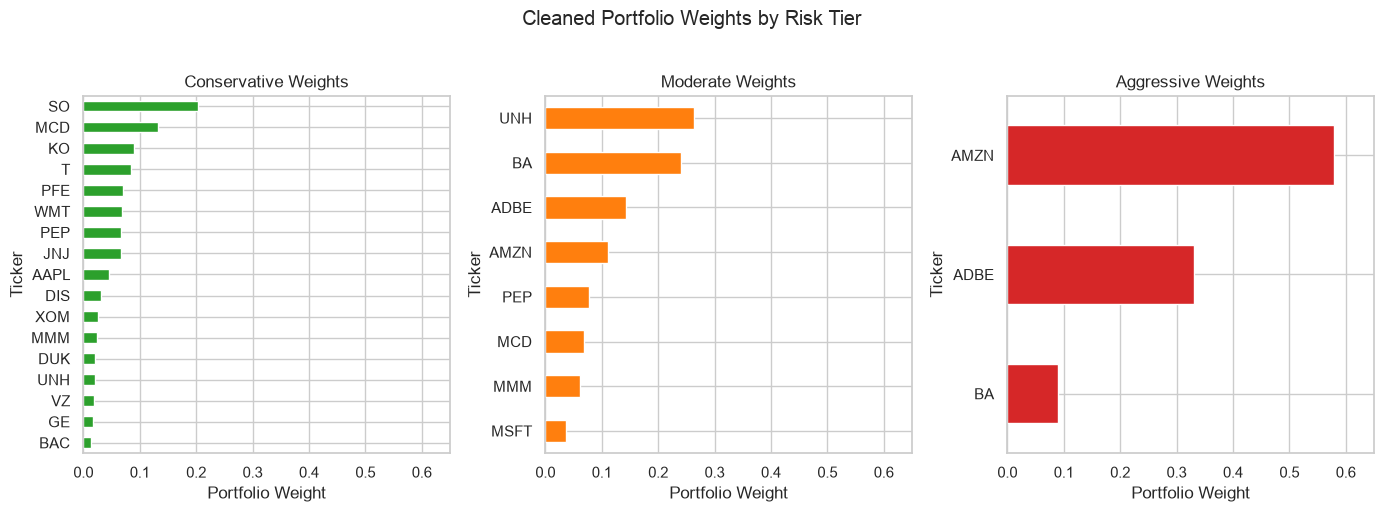

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, tier in zip(axes, RISK_TIER_TARGET_VOLATILITY):
    weights = pd.Series(tier_portfolios[tier]["weights"]).sort_values(ascending=True)
    weights.plot(kind="barh", ax=ax, color=tier_colors[tier])
    ax.set_title(f"{tier} Weights")
    ax.set_xlabel("Portfolio Weight")
    ax.set_ylabel("Ticker")
    ax.set_xlim(0, max(0.65, weights.max() * 1.1))
plt.suptitle("Cleaned Portfolio Weights by Risk Tier", y=1.02)
plt.tight_layout()
plt.show()

**Takeaway:** Conservative is diversified across defensive names, while Aggressive concentrates in a few high-return stocks (notably AMZN), which is what long-only `efficient_risk` requires at 22% vol.

## 4. VaR & Sharpe by Tier

,tier,annualized_return,annualized_vol,sharpe,var_95_pct,n_rebalances,avg_holding_days
0,Conservative,0.075473,0.097101,0.571292,0.964823,1,1224.00
1,Moderate,0.283764,0.140196,1.881394,1.266276,5,237.25
2,Aggressive,0.364722,0.219996,1.566950,1.964333,6,125.40


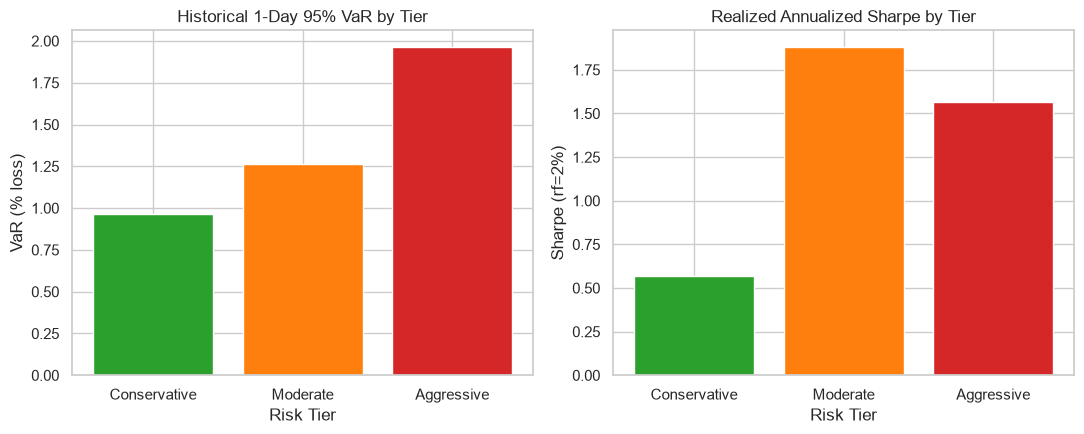

In [12]:
risk_summary = evaluate_tier_risk_metrics(returns, tier_portfolios)
display(risk_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = [tier_colors[t] for t in risk_summary["tier"]]

axes[0].bar(risk_summary["tier"], risk_summary["var_95_pct"], color=colors)
axes[0].set_title("Historical 1-Day 95% VaR by Tier")
axes[0].set_xlabel("Risk Tier")
axes[0].set_ylabel("VaR (% loss)")

axes[1].bar(risk_summary["tier"], risk_summary["sharpe"], color=colors)
axes[1].set_title("Realized Annualized Sharpe by Tier")
axes[1].set_xlabel("Risk Tier")
axes[1].set_ylabel(f"Sharpe (rf={RISK_FREE_RATE:.0%})")

plt.tight_layout()
plt.show()

**Takeaway:** Aggressive has the largest one-day VaR, while Moderate posts the best realized Sharpe over 2013–2018 — higher risk does not automatically mean better risk-adjusted return.

## 5. Rebalancing Simulation

Walk-forward 5% drift rule: whenever any weight drifts more than 5pp from target, reset to target.

Conservative: 1 rebalances | avg holding 1224.0 trading days
Moderate: 5 rebalances | avg holding 237.2 trading days


Aggressive: 6 rebalances | avg holding 125.4 trading days


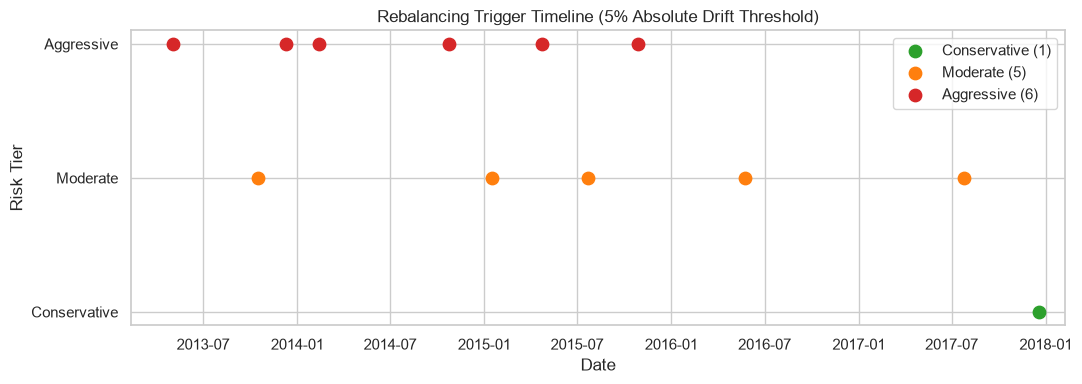

In [13]:
reb_results = {}
for tier in RISK_TIER_TARGET_VOLATILITY:
    reb_results[tier] = simulate_rebalancing(
        returns, tier_portfolios[tier]["weights"], drift_threshold=0.05
    )
    print(
        f"{tier}: {reb_results[tier]['n_rebalances']} rebalances | "
        f"avg holding {reb_results[tier]['avg_holding_period_days']:.1f} trading days"
    )

fig, ax = plt.subplots(figsize=(11, 4))
y_pos = {tier: i for i, tier in enumerate(RISK_TIER_TARGET_VOLATILITY)}
for tier, reb in reb_results.items():
    dates = pd.to_datetime(reb["rebalance_dates"])
    ax.scatter(
        dates,
        [y_pos[tier]] * len(dates),
        s=80, color=tier_colors[tier], label=f"{tier} ({reb['n_rebalances']})", zorder=3,
    )

ax.set_yticks(list(y_pos.values()))
ax.set_yticklabels(list(y_pos.keys()))
ax.set_title("Rebalancing Trigger Timeline (5% Absolute Drift Threshold)")
ax.set_xlabel("Date")
ax.set_ylabel("Risk Tier")
ax.set_xlim(returns.index.min(), returns.index.max())
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Takeaway:** Concentrated Aggressive books hit the 5% drift band more often than the diversified Conservative mix, so higher risk tiers also rebalance more frequently under an absolute drift rule.

## 6. 60/40 Benchmark Comparison

60% equal-weighted Tech/Consumer/Industrials + 40% defensive-equity **bond proxy** (`DUK`, `SO`, `JNJ`, `T`, `VZ`) — not real bonds.

In [14]:
benchmark = build_60_40_benchmark(returns)
tier_returns = {
    tier: portfolio_daily_returns(returns, tier_portfolios[tier]["weights"])
    for tier in RISK_TIER_TARGET_VOLATILITY
}
comparison = compare_to_60_40_benchmark(tier_returns, benchmark)
display(comparison)

print(
    "Bond proxy tickers (NOT real bonds):",
    ", ".join(BOND_PROXY_TICKERS),
)
print("Equity sleeve tickers:", ", ".join(EQUITY_PROXY_TICKERS))

,tier,cumulative_return,annualized_return,annualized_vol,sharpe,max_drawdown
0,Conservative,0.423576,0.075473,0.097101,0.571292,-0.113474
1,Moderate,2.922583,0.283764,0.140196,1.881394,-0.157375
2,Aggressive,4.468887,0.364722,0.219996,1.566950,-0.266615
3,60/40_proxy,1.014586,0.146322,0.109347,1.155238,-0.103049


Bond proxy tickers (NOT real bonds): DUK, SO, JNJ, T, VZ
Equity sleeve tickers: AAPL, ADBE, AMZN, GOOGL, MSFT, DIS, MCD, NKE, SBUX, WMT, BA, HON, MMM


### 6.1 Cumulative returns

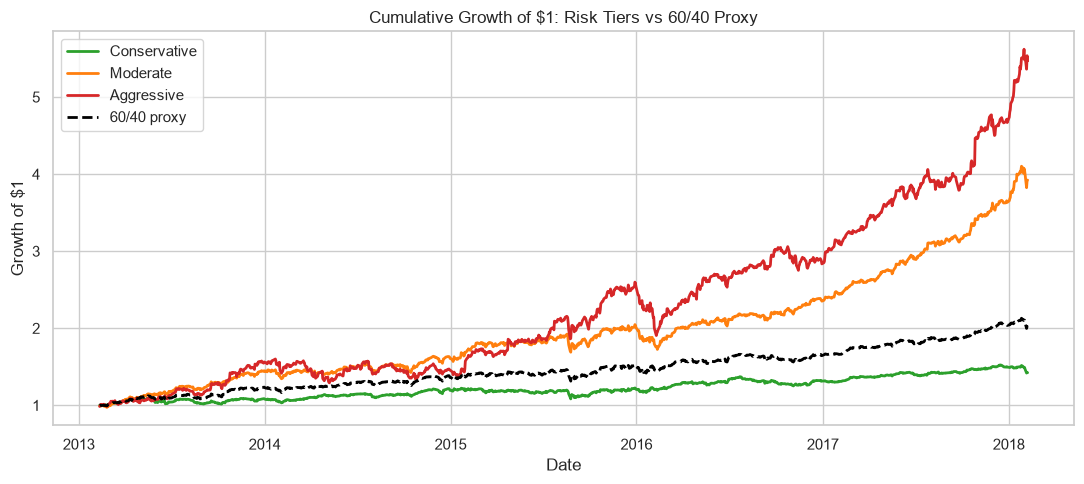

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
for tier, series in tier_returns.items():
    wealth = (1 + series).cumprod()
    ax.plot(wealth.index, wealth.values, color=tier_colors[tier], lw=2, label=tier)
bench_wealth = (1 + benchmark).cumprod()
ax.plot(
    bench_wealth.index, bench_wealth.values,
    color="black", lw=2, ls="--", label="60/40 proxy",
)
ax.set_title("Cumulative Growth of $1: Risk Tiers vs 60/40 Proxy")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Takeaway:** Moderate and Aggressive far outpaced the 60/40 proxy in this equity bull window, while Conservative trailed on return but stayed smoother.

### 6.2 Tier vs benchmark — five comparison metrics

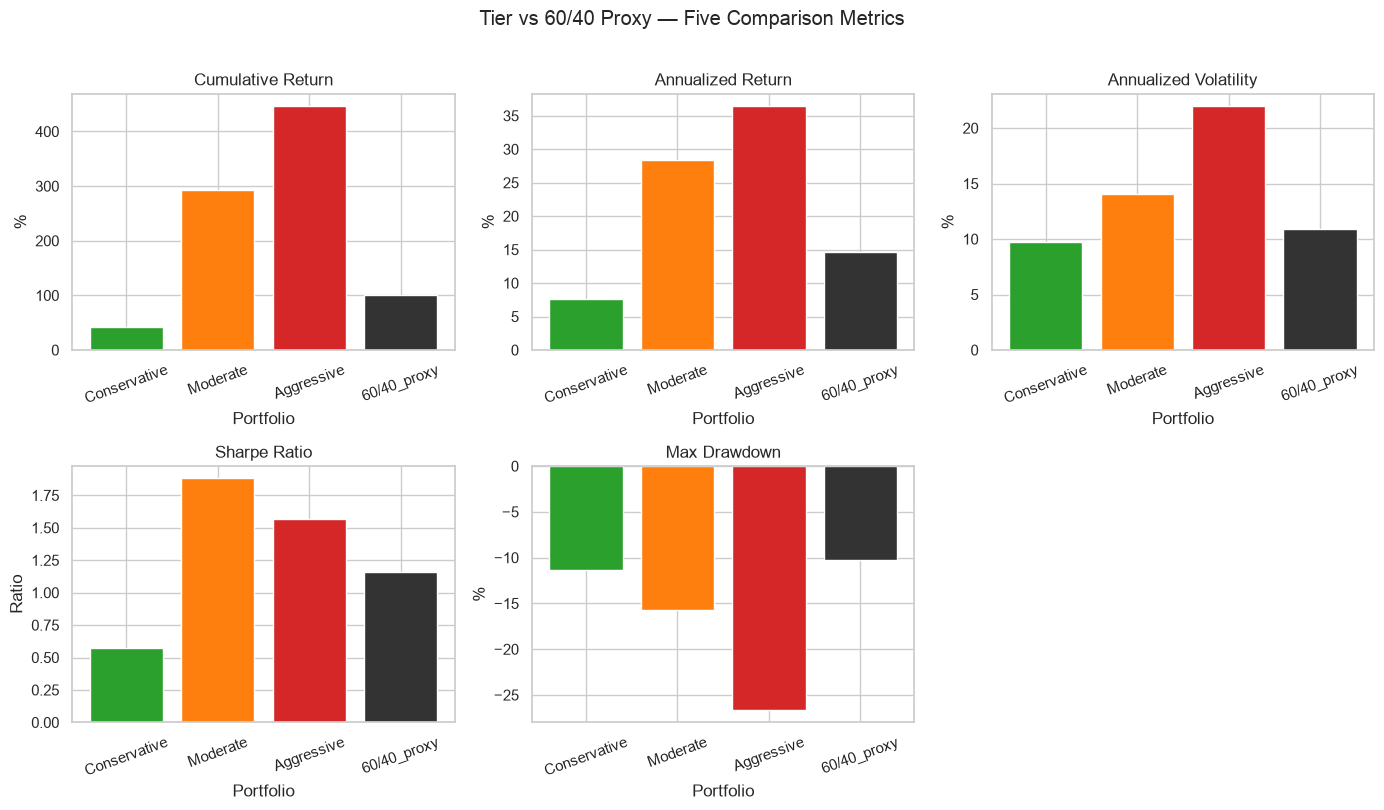

In [16]:
metric_cols = [
    ("cumulative_return", "Cumulative Return", True),
    ("annualized_return", "Annualized Return", True),
    ("annualized_vol", "Annualized Volatility", True),
    ("sharpe", "Sharpe Ratio", False),
    ("max_drawdown", "Max Drawdown", True),
]

plot_df = comparison.copy()
plot_df["tier"] = plot_df["tier"].astype(str)
palette = {**tier_colors, "60/40_proxy": "#333333"}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, (col, title, as_pct) in zip(axes, metric_cols):
    vals = plot_df[col] * 100 if as_pct else plot_df[col]
    bars = ax.bar(plot_df["tier"], vals, color=[palette[t] for t in plot_df["tier"]])
    ax.set_title(title)
    ax.set_xlabel("Portfolio")
    ax.set_ylabel("%" if as_pct else "Ratio")
    ax.tick_params(axis="x", rotation=20)

axes[-1].axis("off")
fig.suptitle("Tier vs 60/40 Proxy — Five Comparison Metrics", y=1.01)
plt.tight_layout()
plt.show()

**Takeaway:** Versus the proxy, Moderate wins on Sharpe while Aggressive leads cumulative return and drawdown depth; remember the 40% sleeve is defensive equity, not bonds, so the benchmark is still equity-like.